In [ ]:
# """
# Poster-quality visualization for damage mapping segmentation results.
# Produces 300 DPI TIFF figures suitable for print at conference poster scale.
# """

# from pathlib import Path
# import re

# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import matplotlib.gridspec as gridspec
# from matplotlib import font_manager
# import numpy as np
# import pandas as pd
# import rasterio as rio
# from IPython.display import display


# # ---------------------------------------------------------------------------
# # Paths & configuration  (unchanged from original)
# # ---------------------------------------------------------------------------
# PROJECT_ROOT = Path('/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2')
# RUNS_DIR = PROJECT_ROOT / 'data/experiments/dev-run-large'
# RUN_NAME = None

# run_dir = Path(
#     '/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2'
#     '/data/experiments/curriculum-learning/curriculum_terramind_2026-04-20_160535'
# )

# pred_dir            = run_dir / 'geotiffs'
# holdout_before_dir  = PROJECT_ROOT / 'data/input/Images_large/Test/Before/S2L2A'
# holdout_after_dir   = PROJECT_ROOT / 'data/input/Images_large/Test/After/S2L2A'
# holdout_label_dir   = PROJECT_ROOT / 'data/input/Images_large/Test/Labels'

# pred_files   = sorted(pred_dir.glob('predicted_map_*_colored.tif'))
# label_files  = sorted(holdout_label_dir.glob('*.tif'))
# before_files = sorted(holdout_before_dir.glob('*.tif'))
# after_files  = sorted(holdout_after_dir.glob('*.tif'))

# print(f'Run directory      : {run_dir}')
# print(f'Prediction files   : {len(pred_files)}')
# print(f'Holdout labels     : {len(label_files)}')
# assert len(pred_files) == len(label_files) == len(before_files) == len(after_files), \
#     'Holdout file counts do not match.'


# # ---------------------------------------------------------------------------
# # Semantics & colors
# # ---------------------------------------------------------------------------
# CLASS_NAMES = {0: 'background', 1: 'no_damage', 2: 'damage'}

# CLASS_COLORS = {
#     0: np.array([42,  54,  66],  dtype=np.uint8),   # background  – cool dark slate
#     1: np.array([52,  168, 130], dtype=np.uint8),   # no damage   – cool teal-green
#     2: np.array([194, 68,  68],  dtype=np.uint8),   # damage      – cool desaturated red
# }

# # Difference panel: cool-toned diverging scheme
# # 0 = background (masked)  → cool blue-gray
# # 1 = correct prediction   → muted steel blue
# # 2 = error / mismatch     → warm amber (contrast anchor)
# DIFF_COLORS = {
#     0: np.array([80,  96,  112], dtype=np.uint8),   # masked      – cool blue-gray
#     1: np.array([74,  144, 196], dtype=np.uint8),   # agreement   – steel blue
#     2: np.array([224, 138,  60], dtype=np.uint8),   # error       – muted amber
# }

# # Legend entries rendered on the figure
# LEGEND_ENTRIES = {
#     'Ground Truth / Prediction': [
#         ('#1e1e1e', 'Background'),
#         ('#3a7d44', 'No Damage'),
#         ('#b4303a', 'Damage'),
#     ],
#     'Difference': [
#         ('#f5f5f0', 'Agreement'),
#         ('#0072b2', 'Error'),
#         ('#1e1e1e', 'Masked (background)'),
#     ],
# }


# # ---------------------------------------------------------------------------
# # Helpers
# # ---------------------------------------------------------------------------
# def find_latest_run(runs_dir: Path) -> Path:
#     candidates = [
#         d for d in sorted(runs_dir.glob('terramind_*'))
#         if (d / 'metrics.txt').exists() and (d / 'geotiffs').exists()
#     ]
#     if not candidates:
#         raise FileNotFoundError(f'No successful runs found in {runs_dir}')
#     return candidates[-1]


# def read_single_band(path: Path) -> np.ndarray:
#     with rio.open(path) as src:
#         return src.read(1)


# def colorize(label: np.ndarray, color_table: dict) -> np.ndarray:
#     rgb = np.zeros((*label.shape, 3), dtype=np.uint8)
#     for cls, color in color_table.items():
#         rgb[label == cls] = color
#     return rgb


# def build_diff_map(truth: np.ndarray, pred: np.ndarray) -> np.ndarray:
#     """Three-state difference: masked / agreement / error."""
#     diff = np.zeros_like(truth, dtype=np.uint8)          # 0 = masked
#     valid = truth != 0
#     diff[valid & (truth == pred)] = 1                     # 1 = correct
#     diff[valid & (truth != pred)] = 2                     # 2 = wrong
#     return colorize(diff, DIFF_COLORS)


# def parse_metrics(metrics_path: Path) -> pd.DataFrame:
#     pattern = re.compile(
#         r'Image\s+(?P<image_id>\d+)\s+metrics:\s+'
#         r'Accuracy:\s+(?P<Accuracy>[0-9.]+)\s+'
#         r'Precision:\s+(?P<Precision>[0-9.]+)\s+'
#         r'Recall:\s+(?P<Recall>[0-9.]+)\s+'
#         r'F1:\s+(?P<F1>[0-9.]+)\s+'
#         r'IoU:\s+(?P<IoU>[0-9.]+)',
#         re.MULTILINE,
#     )
#     records = []
#     for m in pattern.finditer(metrics_path.read_text()):
#         row = m.groupdict()
#         row['image_id'] = int(row['image_id'])
#         for k in ('Accuracy', 'Precision', 'Recall', 'F1', 'IoU'):
#             row[k] = float(row[k])
#         records.append(row)
#     return pd.DataFrame(records).sort_values('image_id').reset_index(drop=True)


# # ---------------------------------------------------------------------------
# # Poster figure
# # ---------------------------------------------------------------------------
# POSTER_DPI = 300
# PANEL_INCH = 4.5          # width of each image panel in inches
# CBAR_PAD   = 0.18         # space between panels (fraction of panel width)


# def make_poster_figure(
#     tile_idx: int,
#     label_rgb:      np.ndarray,
#     prediction_rgb: np.ndarray,
#     diff_rgb:       np.ndarray,
#     metrics_row:    pd.Series,
#     label_name:     str,
#     pred_name:      str,
#     output_path:    Path,
# ) -> None:
#     """
#     Render a single three-panel poster figure and save as 300 DPI TIFF.

#     Parameters
#     ----------
#     tile_idx       : zero-based tile index (used only in the subtitle)
#     label_rgb      : H×W×3 uint8 – colourised ground truth
#     prediction_rgb : H×W×3 uint8 – colourised prediction
#     diff_rgb       : H×W×3 uint8 – colourised difference map
#     metrics_row    : pandas Series with IoU, F1, Precision, Recall, Accuracy
#     label_name     : filename of the label GeoTIFF (subtitle text)
#     pred_name      : filename of the prediction GeoTIFF (subtitle text)
#     output_path    : destination .tiff path
#     """
#     # ------------------------------------------------------------------
#     # Typography  (fall back to DejaVu Sans if Helvetica is unavailable)
#     # ------------------------------------------------------------------
#     available = {f.name for f in font_manager.fontManager.ttflist}
#     sans = 'Helvetica' if 'Helvetica' in available else 'DejaVu Sans'

#     TITLE_SIZE  = 22   # panel letter + label  (A) Ground Truth
#     METRIC_SIZE = 16   # IoU / F1 annotation
#     LEGEND_SIZE = 13
#     SUPTITLE_SIZE = 14

#     # ------------------------------------------------------------------
#     # Layout
#     # ------------------------------------------------------------------
#     fig_w  = PANEL_INCH * 3 + PANEL_INCH * CBAR_PAD * 2 + 1.6   # +1.6" legend column
#     h, w   = label_rgb.shape[:2]
#     aspect = h / w
#     fig_h  = PANEL_INCH * aspect + 1.4

#     fig = plt.figure(figsize=(fig_w, fig_h), dpi=POSTER_DPI, facecolor='white')

#     # Reserve the rightmost ~1.6" for the legend; panels occupy the rest
#     legend_frac = 1.6 / fig_w          # fraction of total width for legend column
#     panels_right = 1.0 - legend_frac - 0.01

#     gs = gridspec.GridSpec(
#         1, 3,
#         figure=fig,
#         left=0.01, right=panels_right,
#         top=0.82,  bottom=0.05,
#         wspace=0.04,
#     )

#     ax_truth = fig.add_subplot(gs[0, 0])
#     ax_pred  = fig.add_subplot(gs[0, 1])
#     ax_diff  = fig.add_subplot(gs[0, 2])

#     panels = [
#         (ax_truth, label_rgb,      '(A)  Ground Truth'),
#         (ax_pred,  prediction_rgb, '(B)  Predicted'),
#         (ax_diff,  diff_rgb,       '(C)  Difference'),
#     ]

#     for ax, img, title in panels:
#         ax.imshow(img, interpolation='nearest')
#         ax.set_title(
#             title,
#             fontsize=TITLE_SIZE,
#             fontfamily=sans,
#             fontweight='bold',
#             color='#111111',
#             pad=8,
#         )
#         ax.set_xticks([])
#         ax.set_yticks([])
#         for spine in ax.spines.values():
#             spine.set_visible(False)

#     # (metrics rendered in the reserved right column — see metrics box below)

#     # ------------------------------------------------------------------
#     # Global title / suptitle (file info, small)
#     # ------------------------------------------------------------------
#     fig.text(
#         0.5, 0.97,
#         'Building Damage Segmentation  —  Holdout Evaluation',
#         ha='center', va='top',
#         fontsize=18, fontfamily=sans, fontweight='bold', color='#111111',
#     )
#     fig.text(
#         0.5, 0.93,
#         f'Tile {tile_idx + 1}   |   Label: {label_name}   |   Pred: {pred_name}',
#         ha='center', va='top',
#         fontsize=SUPTITLE_SIZE, fontfamily=sans, color='#555555',
#         style='italic',
#     )

#     # ------------------------------------------------------------------
#     # Legend — placed in the reserved right column, top-aligned, no overlap
#     # ------------------------------------------------------------------
#     def _patch(hex_col, label):
#         return mpatches.Patch(facecolor=hex_col, edgecolor='#aabbcc',
#                               linewidth=0.6, label=label)

#     legend_handles = [
#         _patch('#2a3642', 'Background (masked)'),
#         _patch('#34a882', 'No Damage'),
#         _patch('#c24444', 'Damage'),
#         _patch('#4a90c4', 'Agreement'),
#         _patch('#e08a3c', 'Error'),
#     ]
#     # bbox_to_anchor in figure coordinates: left edge of the legend column
#     legend_x = panels_right + 0.02
#     fig.legend(
#         handles=legend_handles,
#         loc='upper left',
#         bbox_to_anchor=(legend_x, 0.84),   # aligns with top of plot area
#         bbox_transform=fig.transFigure,
#         ncol=1,
#         frameon=True,
#         framealpha=1.0,
#         edgecolor='#ccd6e0',
#         facecolor='#f7f9fb',
#         fontsize=LEGEND_SIZE,
#         prop={'family': sans, 'size': LEGEND_SIZE},
#         handlelength=1.5,
#         handleheight=1.1,
#         borderpad=0.8,
#         labelspacing=0.7,
#         title='Legend',
#         title_fontsize=LEGEND_SIZE,
#     )

#     # ------------------------------------------------------------------
#     # Metrics box — reserved right column, bottom-aligned, no overlap
#     # ------------------------------------------------------------------
#     metrics = [
#         ('IoU',       f'{metrics_row.IoU:.4f}'),
#         ('F1',        f'{metrics_row.F1:.4f}'),
#         ('Precision', f'{metrics_row.Precision:.4f}'),
#         ('Recall',    f'{metrics_row.Recall:.4f}'),
#         ('Accuracy',  f'{metrics_row.Accuracy:.4f}'),
#     ]
#     # Build a two-column text block: label (right-aligned) · value (left-aligned)
#     metrics_lines = '\n'.join(f'{k:<10}{v}' for k, v in metrics)
#     metrics_box_x = legend_x          # same left edge as the legend
#     metrics_box_y = 0.10              # anchored near the figure bottom

#     fig.text(
#         metrics_box_x, metrics_box_y + 0.085,
#         'Metrics',
#         transform=fig.transFigure,
#         ha='left', va='bottom',
#         fontsize=LEGEND_SIZE,
#         fontfamily=sans,
#         fontweight='bold',
#         color='#2a3642',
#     )
#     t = fig.text(
#         metrics_box_x, metrics_box_y,
#         metrics_lines,
#         transform=fig.transFigure,
#         ha='left', va='bottom',
#         fontsize=LEGEND_SIZE - 1,
#         fontfamily='monospace',
#         color='#2a3642',
#         linespacing=1.65,
#         bbox=dict(
#             boxstyle='round,pad=0.55',
#             facecolor='#f7f9fb',
#             edgecolor='#ccd6e0',
#             linewidth=0.8,
#         ),
#     )

#     # ------------------------------------------------------------------
#     # Save
#     # ------------------------------------------------------------------
#     output_path.parent.mkdir(parents=True, exist_ok=True)
#     fig.savefig(
#         output_path,
#         dpi=POSTER_DPI,
#         format='png',
#         bbox_inches='tight',
#         pad_inches=0.0,          # no extra white border
#     )
#     plt.close(fig)
#     print(f'  ✓  Saved  →  {output_path}')


# # ---------------------------------------------------------------------------
# # Main loop
# # ---------------------------------------------------------------------------
# metrics_df = parse_metrics(run_dir / 'metrics.txt')
# metrics_df['label_file']      = [p.name for p in label_files]
# metrics_df['prediction_file'] = [p.name for p in pred_files]
# display(metrics_df)

# poster_dir = run_dir / 'poster_figures'
# poster_dir.mkdir(exist_ok=True)

# print(f'\nGenerating {len(pred_files)} poster-quality figure(s) → {poster_dir}\n')

# for tile_idx in range(len(pred_files)):
#     label      = read_single_band(label_files[tile_idx]).astype(np.uint8)
#     prediction = read_single_band(pred_files[tile_idx]).astype(np.uint8)

#     label_rgb      = colorize(label, CLASS_COLORS)
#     prediction_rgb = colorize(prediction, CLASS_COLORS)
#     diff_rgb       = build_diff_map(label, prediction)

#     row = metrics_df.iloc[tile_idx]
#     out_path = poster_dir / f'poster_tile_{tile_idx + 1:02d}.png'

#     make_poster_figure(
#         tile_idx       = tile_idx,
#         label_rgb      = label_rgb,
#         prediction_rgb = prediction_rgb,
#         diff_rgb       = diff_rgb,
#         metrics_row    = row,
#         label_name     = label_files[tile_idx].name,
#         pred_name      = pred_files[tile_idx].name,
#         output_path    = out_path,
#     )

# print('\nAll tiles complete.')

In [ ]:
import sys
sys.path.append("../../")
from damage_mapping.utils.reconstruct_tiff_to_png import main
config_keys=[
        "change.method",
        "curriculum.flood_epochs",
        "curriculum.conflict_epochs"
    ]
for rundir in [
                # "curriculum_terramind_2026-04-20_160535",
                # "curriculum_terramind_2026-04-20_163845",
                # "curriculum_terramind_2026-04-20_174834",
                # "curriculum_terramind_2026-04-20_181115",
                # "curriculum_terramind_2026-04-20_182921",
                # "curriculum_terramind_2026-04-20_191318",
                # "curriculum_terramind_2026-04-20_203517",
                # "curriculum_terramind_2026-04-20_235126",
                # "curriculum_terramind_2026-04-21_002019",
                "curriculum_terramind_2026-05-04_154141"
                ]:
    main("curriculum-learning/"+ rundir, config_keys)
main("curriculum-learning/curriculum_terramind_2026-05-14_135105", config_keys=config_keys, dataset="flood")




Run directory      : curriculum-learning/curriculum_terramind_2026-04-20_203517
Prediction files   : 2
Holdout labels     : 2
Generating 2 poster-quality figure(s) → /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/curriculum-learning/curriculum_terramind_2026-04-20_203517/poster_figures
  ✓  Saved  →  /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/curriculum-learning/curriculum_terramind_2026-04-20_203517/poster_figures/poster_tile_01.png
  ✓  Saved  →  /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/curriculum-learning/curriculum_terramind_2026-04-20_203517/poster_figures/poster_tile_02.png

Run directory      : curriculum-learning/curriculum_terramind_2026-04-20_235126
Prediction files   : 2
Holdout labels     : 2
Generating 2 poster-quality figure(s) → /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/curriculum-learning/curriculum_t

In [2]:
for rundir in ["terramind_2026-04-02_153713-siamese-fusion",
               "terramind_2026-04-02_154605-attension_based",
            #    "terramind_2026-04-02_160926,"
               "terramind_2026-04-02_151736-all-concat",
               "terramind_2026-03-27_193712-best-ep3-ce"
               ]:

    main("dev-run-large/"+rundir)


Run directory      : dev-run-large/terramind_2026-04-02_153713-siamese-fusion
Prediction files   : 2
Holdout labels     : 2
Generating 2 poster-quality figure(s) → /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-run-large/terramind_2026-04-02_153713-siamese-fusion/poster_figures
  ✓  Saved  →  /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-run-large/terramind_2026-04-02_153713-siamese-fusion/poster_figures/poster_tile_01.png
  ✓  Saved  →  /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-run-large/terramind_2026-04-02_153713-siamese-fusion/poster_figures/poster_tile_02.png

Run directory      : dev-run-large/terramind_2026-04-02_154605-attension_based
Prediction files   : 2
Holdout labels     : 2
Generating 2 poster-quality figure(s) → /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-run-large/terramind_2026-04-02_154605

Found 16 label files in /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/Labels


Scanning labels: 100%|██████████| 16/16 [00:00<00:00, 59.08it/s]



Per-chip stats saved to: label_audit_outputs/per_chip_stats.csv

================ Dataset-wide class distribution ================
Total chips           : 16
Total valid pixels    : 4,194,304
Total ignored pixels  : 0
  Class 0 ( background):      2,476,092  ( 59.03%)
  Class 1 ( not_damage):      1,477,618  ( 35.23%)
  Class 2 (     damage):        240,594  (  5.74%)

✅ No unexpected label values found.

================ Per-class chip presence ================
  Chips containing class 0 ( background): 16/16  (100.0%)
  Chips containing class 1 ( not_damage): 16/16  (100.0%)
  Chips containing class 2 (     damage): 16/16  (100.0%)

  Chips with ONLY background      : 0
  Chips with NO damage class      : 0  (0.0%)
  Chips with ONLY damage pixels   : 0

================ Health checks ================
  ✅ Damage class fraction is reasonable (5.74%).


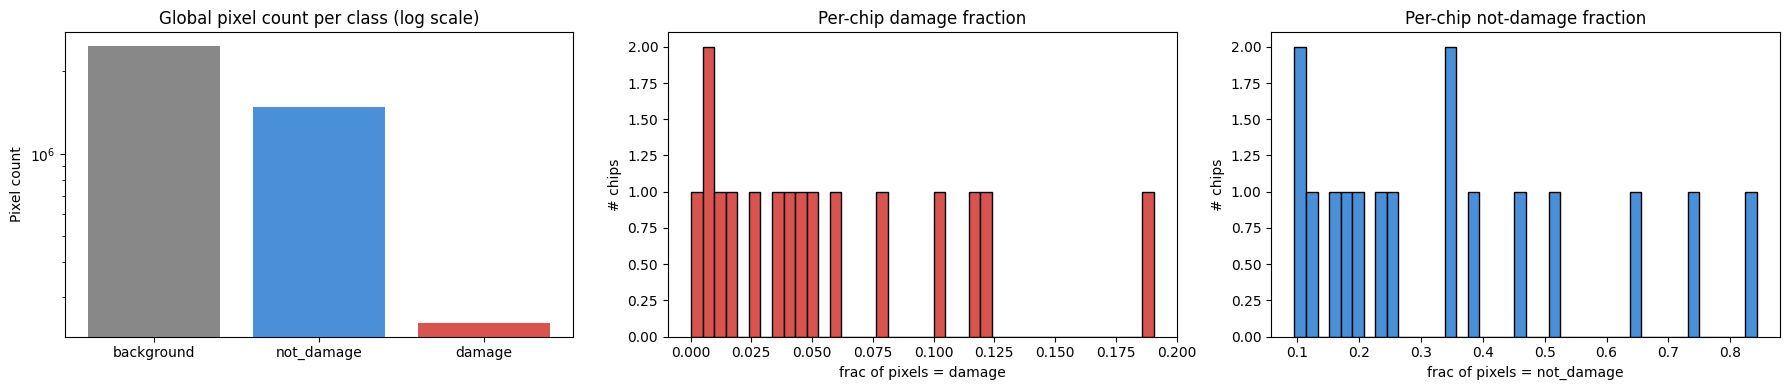

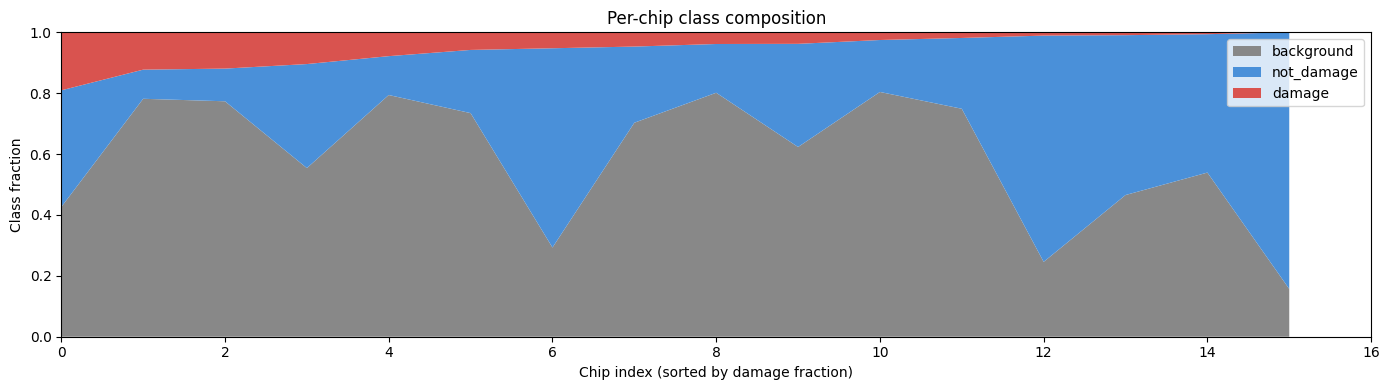


ℹ️  ORIGINAL_LABELS_DIR not set — skipping co-occurrence check.
   To enable: set ORIGINAL_LABELS_DIR to your SenFloods11 original labels folder.

✅ Audit complete. Outputs in: /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/damage_mapping/examples/label_audit_outputs


In [2]:
# ============================================================
# Step 2: Class Distribution Audit for Mapped Flood Labels
# ============================================================
import os
from pathlib import Path
from glob import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import rasterio
from tqdm import tqdm
import matplotlib.pyplot as plt

# ----------------- CONFIG -----------------
LABELS_DIR = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/Labels")
ORIGINAL_LABELS_DIR = None   # set to a Path if you have original SenFloods11 labels for co-occurrence check
NUM_CLASSES = 3              # 0=background, 1=not-damage, 2=damage
IGNORE_VALUE = -1            # set to None if no ignore index
OUTPUT_DIR = Path("./label_audit_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = {0: "background", 1: "not_damage", 2: "damage"}

# ----------------- DISCOVER FILES -----------------
label_files = sorted(glob(str(LABELS_DIR / "*.tif")) + glob(str(LABELS_DIR / "*.tiff")))
print(f"Found {len(label_files)} label files in {LABELS_DIR}")
assert len(label_files) > 0, "No label files found — check the path / extension."

# ----------------- PER-CHIP STATS -----------------
records = []
global_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
ignored_total = 0
unexpected_values = defaultdict(int)

for fp in tqdm(label_files, desc="Scanning labels"):
    with rasterio.open(fp) as src:
        arr = src.read(1)

    total = arr.size

    # Handle ignore index
    if IGNORE_VALUE is not None:
        ignore_mask = arr == IGNORE_VALUE
        n_ignore = int(ignore_mask.sum())
        ignored_total += n_ignore
        valid = arr[~ignore_mask]
    else:
        n_ignore = 0
        valid = arr.ravel()

    # Detect unexpected label values
    uniq, cnts = np.unique(valid, return_counts=True)
    chip_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    for u, c in zip(uniq, cnts):
        if 0 <= u < NUM_CLASSES:
            chip_counts[u] = c
        else:
            unexpected_values[int(u)] += int(c)

    global_counts += chip_counts

    rec = {
        "file": os.path.basename(fp),
        "H": arr.shape[0],
        "W": arr.shape[1],
        "n_pixels_valid": int(valid.size),
        "n_pixels_ignore": n_ignore,
    }
    for k in range(NUM_CLASSES):
        rec[f"count_{CLASS_NAMES[k]}"] = int(chip_counts[k])
        rec[f"frac_{CLASS_NAMES[k]}"] = float(chip_counts[k] / max(valid.size, 1))
    rec["has_damage"] = bool(chip_counts[2] > 0)
    rec["has_not_damage"] = bool(chip_counts[1] > 0)
    rec["damage_dominant"] = bool(chip_counts[2] / max(valid.size, 1) > 0.5)
    records.append(rec)

df = pd.DataFrame(records)
df.to_csv(OUTPUT_DIR / "per_chip_stats.csv", index=False)
print(f"\nPer-chip stats saved to: {OUTPUT_DIR/'per_chip_stats.csv'}")

# ----------------- DATASET-WIDE SUMMARY -----------------
total_valid = global_counts.sum()
print("\n================ Dataset-wide class distribution ================")
print(f"Total chips           : {len(df)}")
print(f"Total valid pixels    : {total_valid:,}")
print(f"Total ignored pixels  : {ignored_total:,}")

summary_rows = []
for k in range(NUM_CLASSES):
    pct = 100 * global_counts[k] / total_valid if total_valid > 0 else 0
    print(f"  Class {k} ({CLASS_NAMES[k]:>11}): {global_counts[k]:>14,}  ({pct:6.2f}%)")
    summary_rows.append({
        "class_id": k,
        "class_name": CLASS_NAMES[k],
        "pixel_count": int(global_counts[k]),
        "pixel_pct": float(pct),
        "chips_containing": int(df[f"count_{CLASS_NAMES[k]}"].gt(0).sum()),
        "chips_containing_pct": float(100 * df[f"count_{CLASS_NAMES[k]}"].gt(0).mean()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / "class_summary.csv", index=False)

if unexpected_values:
    print("\n⚠️  Unexpected label values detected (NOT in [0..NUM_CLASSES-1] and not ignore):")
    for v, c in sorted(unexpected_values.items()):
        print(f"   value={v}: {c:,} pixels")
else:
    print("\n✅ No unexpected label values found.")

# ----------------- CHIP-LEVEL PRESENCE -----------------
print("\n================ Per-class chip presence ================")
for k in range(NUM_CLASSES):
    n = int(df[f"count_{CLASS_NAMES[k]}"].gt(0).sum())
    print(f"  Chips containing class {k} ({CLASS_NAMES[k]:>11}): "
          f"{n}/{len(df)}  ({100*n/len(df):.1f}%)")

n_only_bg = int(((df["count_not_damage"] == 0) & (df["count_damage"] == 0)).sum())
n_only_damage = int(((df["count_background"] == 0) & (df["count_not_damage"] == 0)).sum())
n_no_damage = int((df["count_damage"] == 0).sum())
print(f"\n  Chips with ONLY background      : {n_only_bg}")
print(f"  Chips with NO damage class      : {n_no_damage}  ({100*n_no_damage/len(df):.1f}%)")
print(f"  Chips with ONLY damage pixels   : {n_only_damage}")

# ----------------- HEALTH FLAGS -----------------
print("\n================ Health checks ================")
flags = []

frac_damage = global_counts[2] / total_valid
frac_notdmg = global_counts[1] / total_valid
frac_bg     = global_counts[0] / total_valid

if frac_damage < 0.005:
    flags.append(f"❌ Damage class extremely rare ({100*frac_damage:.3f}%) — model may collapse to background.")
elif frac_damage < 0.02:
    flags.append(f"⚠️  Damage class is rare ({100*frac_damage:.2f}%) — consider class weighting / focal loss.")
else:
    flags.append(f"✅ Damage class fraction is reasonable ({100*frac_damage:.2f}%).")

if frac_notdmg < 0.001:
    flags.append("⚠️  Class 1 (not-damage) is nearly absent — your ag mask may be too permissive "
                 "(treating all flood as agricultural). Cross-check ag mask coverage.")
if frac_bg < 0.1:
    flags.append("⚠️  Background class very small — possibly over-aggressive flood filtering.")

if df["damage_dominant"].mean() > 0.7:
    flags.append("⚠️  >70% of chips are damage-dominant — limited negatives for the model to learn from.")

if unexpected_values:
    flags.append("❌ Unexpected label values present — fix mapping before training.")

for f in flags:
    print("  " + f)

# ----------------- VISUALIZATIONS -----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (a) global class distribution
axes[0].bar([CLASS_NAMES[k] for k in range(NUM_CLASSES)],
            [global_counts[k] for k in range(NUM_CLASSES)],
            color=["#888", "#4a90d9", "#d9534f"])
axes[0].set_yscale("log")
axes[0].set_title("Global pixel count per class (log scale)")
axes[0].set_ylabel("Pixel count")

# (b) per-chip damage fraction histogram
axes[1].hist(df["frac_damage"], bins=40, color="#d9534f", edgecolor="black")
axes[1].set_title("Per-chip damage fraction")
axes[1].set_xlabel("frac of pixels = damage")
axes[1].set_ylabel("# chips")

# (c) per-chip not-damage fraction histogram
axes[2].hist(df["frac_not_damage"], bins=40, color="#4a90d9", edgecolor="black")
axes[2].set_title("Per-chip not-damage fraction")
axes[2].set_xlabel("frac of pixels = not_damage")
axes[2].set_ylabel("# chips")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "class_distributions.png", dpi=120)
plt.show()

# Stacked composition per chip (sorted)
df_sorted = df.sort_values("frac_damage", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(14, 4))
ax.stackplot(np.arange(len(df_sorted)),
             df_sorted["frac_background"],
             df_sorted["frac_not_damage"],
             df_sorted["frac_damage"],
             labels=["background", "not_damage", "damage"],
             colors=["#888", "#4a90d9", "#d9534f"])
ax.set_xlim(0, len(df_sorted))
ax.set_ylim(0, 1)
ax.set_xlabel("Chip index (sorted by damage fraction)")
ax.set_ylabel("Class fraction")
ax.set_title("Per-chip class composition")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "per_chip_stack.png", dpi=120)
plt.show()

# ----------------- (OPTIONAL) CO-OCCURRENCE WITH ORIGINAL -----------------
if ORIGINAL_LABELS_DIR is not None:
    print("\n================ Co-occurrence check vs original SenFloods11 labels ================")
    from itertools import islice

    def find_original(fp_new):
        # Adjust this matcher to your filename convention
        name = os.path.basename(fp_new)
        candidate = Path(ORIGINAL_LABELS_DIR) / name
        return candidate if candidate.exists() else None

    confusion = np.zeros((3, 2), dtype=np.int64)  # rows: new {0,1,2}, cols: orig {0,1}
    n_checked = 0
    for fp in tqdm(label_files, desc="Co-occurrence"):
        orig_fp = find_original(fp)
        if orig_fp is None:
            continue
        with rasterio.open(fp) as s_new, rasterio.open(orig_fp) as s_old:
            new_arr = s_new.read(1)
            old_arr = s_old.read(1)
        if new_arr.shape != old_arr.shape:
            continue
        mask = (old_arr != -1) & (new_arr != IGNORE_VALUE if IGNORE_VALUE is not None else True)
        for new_v in range(3):
            for old_v in [0, 1]:
                confusion[new_v, old_v] += int(((new_arr == new_v) & (old_arr == old_v) & mask).sum())
        n_checked += 1

    if n_checked > 0:
        print(f"Compared {n_checked} chips.")
        print("Rows = new label (0/1/2), Cols = original (0=no_water, 1=water)")
        print(pd.DataFrame(confusion,
                           index=["new_0_bg", "new_1_notdmg", "new_2_dmg"],
                           columns=["orig_0_nowater", "orig_1_water"]))

        # Validation rules
        leak_1 = confusion[1, 0]   # mapped to not_damage but original says no water
        leak_2 = confusion[2, 0]   # mapped to damage but original says no water
        miss   = confusion[0, 1]   # original water but mapped to background
        print(f"\n  Pixels mapped to NOT-DAMAGE but originally NO water: {leak_1:,}  (should be 0)")
        print(f"  Pixels mapped to DAMAGE but originally NO water    : {leak_2:,}  (should be 0)")
        print(f"  Pixels originally WATER but mapped to BACKGROUND   : {miss:,}  (should be 0)")
        if leak_1 == 0 and leak_2 == 0 and miss == 0:
            print("  ✅ Mapping is a strict subset of original water pixels.")
        else:
            print("  ❌ Mapping inconsistency detected — investigate.")
    else:
        print("No matching original files found. Adjust `find_original()` for your naming.")
else:
    print("\nℹ️  ORIGINAL_LABELS_DIR not set — skipping co-occurrence check.")
    print("   To enable: set ORIGINAL_LABELS_DIR to your SenFloods11 original labels folder.")

print("\n✅ Audit complete. Outputs in:", OUTPUT_DIR.resolve())

Found 16 label files in /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/Labels


Auditing labels: 100%|██████████| 16/16 [00:00<00:00, 253.27it/s]


Per-chip stats saved → label_audit_outputs/per_chip_stats.csv

===== DATASET-WIDE CLASS DISTRIBUTION =====
  Class 0 (              Ignore):       2,476,092 pixels  (59.035%)
  Class 1 (    Non-flooded crop):       1,477,618 pixels  (35.229%)
  Class 2 (        Flooded crop):         240,594 pixels  ( 5.736%)

✅ All pixel values are within {0,1,2}.

===== CHIP-LEVEL COVERAGE =====
Total chips                     : 16
Chips with ANY class 2 (damage) : 16 (100.0%)
Chips with ANY class 1 (no-dmg) : 16 (100.0%)
Chips with class2 ≥ 0.1%   : 15
Chips with class1 ≥ 0.1%   : 16
Chips that are 100% ignore (0)  : 0  ← candidates to drop
Chips with NO crop pixels at all: 0

===== CO-OCCURRENCE OF CLASSES PER CHIP =====
has_class2  True
has_class1      
True          16

===== QUALITY FLAGS =====
  All-ignore chips (drop?)                : 0
  No class-2 (flooded crop)               : 0
  No class-1 (non-flooded crop)           : 0
  Tiny class-2 (<0.1% pixels)             : 1
  Class-2 dominant 

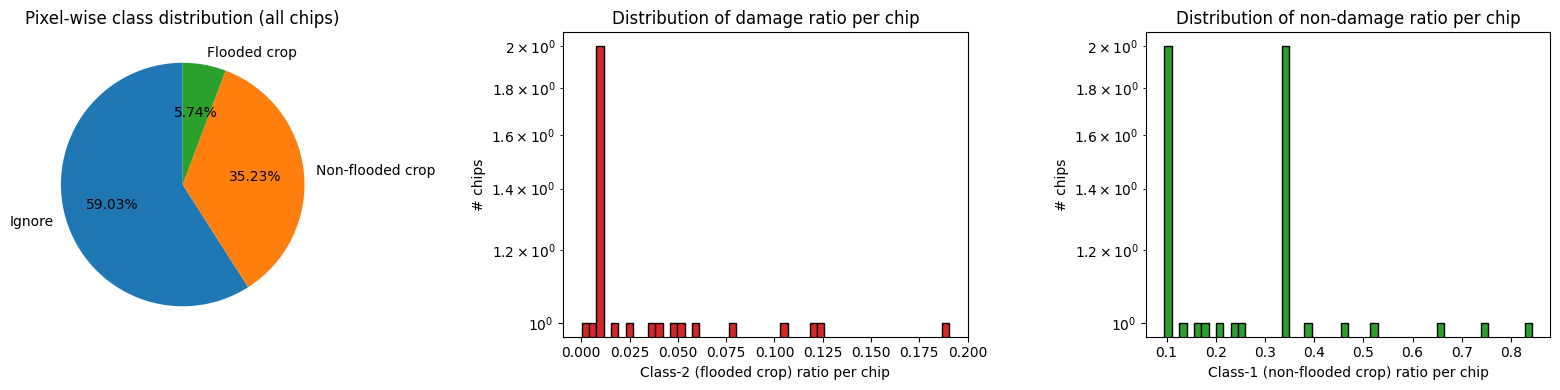


Plots saved → label_audit_outputs/class_distribution_plots.png

===== RECOMMENDED CHIPS FOR VISUAL INSPECTION =====

-- Top-10 highest damage ratio --
                     file  ratio_class2
  LabelMask_USA_86502.tif      0.190544
 LabelMask_USA_170264.tif      0.122612
 LabelMask_USA_217598.tif      0.119133
 LabelMask_USA_955053.tif      0.104229
LabelMask_USA_1068362.tif      0.078236
 LabelMask_USA_595451.tif      0.057804
 LabelMask_USA_430764.tif      0.052311
  LabelMask_USA_58086.tif      0.046764
  LabelMask_USA_11422.tif      0.038319
 LabelMask_USA_770353.tif      0.037792

-- 10 balanced chips (both classes >5%) --
                     file  ratio_class1  ratio_class2
LabelMask_USA_1068362.tif      0.127705      0.078236
 LabelMask_USA_170264.tif      0.095692      0.122612
 LabelMask_USA_217598.tif      0.107376      0.119133
 LabelMask_USA_430764.tif      0.654633      0.052311
 LabelMask_USA_595451.tif      0.207573      0.057804
  LabelMask_USA_86502.tif      0.383327 

In [3]:
"""
Quantitative sanity check for cross-domain label mapping.
Final labels expected:
    0 = Ignore (background, invalid, permanent water, non-cropland, etc.)
    1 = Non-flooded crop
    2 = Flooded crop (damage)
"""

import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import rasterio
from tqdm import tqdm
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------
LABEL_DIR = Path(
    "/users/PGS0218/julina/projects/geography/damage_mapping_terramind/"
    "V2/data/input/flood_data/Train/Labels"
)
OUT_DIR = Path("./label_audit_outputs")
OUT_DIR.mkdir(exist_ok=True, parents=True)

VALID_CLASSES = {0, 1, 2}
CLASS_NAMES = {0: "Ignore", 1: "Non-flooded crop", 2: "Flooded crop"}

# Thresholds for "interesting" chips
MIN_CLASS2_RATIO = 0.001   # >=0.1% flooded crop
MIN_CLASS1_RATIO = 0.001   # >=0.1% non-flooded crop


# ----------------------------------------------------------------------
# 1. Collect label files
# ----------------------------------------------------------------------
label_files = sorted([p for p in LABEL_DIR.glob("*.tif")] +
                     [p for p in LABEL_DIR.glob("*.tiff")])
print(f"Found {len(label_files)} label files in {LABEL_DIR}")
assert len(label_files) > 0, "No label files found — check path."


# ----------------------------------------------------------------------
# 2. Iterate and gather per-chip stats
# ----------------------------------------------------------------------
records = []
global_counts = defaultdict(int)
unexpected_values = defaultdict(int)

for fp in tqdm(label_files, desc="Auditing labels"):
    with rasterio.open(fp) as src:
        arr = src.read(1)
        H, W = arr.shape
        total = H * W

        unique, counts = np.unique(arr, return_counts=True)
        chip_dist = dict(zip(unique.tolist(), counts.tolist()))

        # Track unexpected values
        for v, c in chip_dist.items():
            if v not in VALID_CLASSES:
                unexpected_values[v] += c
            else:
                global_counts[v] += c

        rec = {
            "file": fp.name,
            "height": H,
            "width": W,
            "n_pixels": total,
            "n_class0": chip_dist.get(0, 0),
            "n_class1": chip_dist.get(1, 0),
            "n_class2": chip_dist.get(2, 0),
            "ratio_class0": chip_dist.get(0, 0) / total,
            "ratio_class1": chip_dist.get(1, 0) / total,
            "ratio_class2": chip_dist.get(2, 0) / total,
            "has_class1": chip_dist.get(1, 0) > 0,
            "has_class2": chip_dist.get(2, 0) > 0,
            "unexpected_values": [v for v in chip_dist if v not in VALID_CLASSES],
        }
        records.append(rec)

df = pd.DataFrame(records)
df.to_csv(OUT_DIR / "per_chip_stats.csv", index=False)
print(f"\nPer-chip stats saved → {OUT_DIR/'per_chip_stats.csv'}")


# ----------------------------------------------------------------------
# 3. Dataset-wide summary
# ----------------------------------------------------------------------
total_pixels = sum(global_counts.values())
print("\n===== DATASET-WIDE CLASS DISTRIBUTION =====")
summary_rows = []
for c in sorted(VALID_CLASSES):
    n = global_counts.get(c, 0)
    pct = 100 * n / total_pixels if total_pixels else 0
    print(f"  Class {c} ({CLASS_NAMES[c]:>20}): "
          f"{n:>15,d} pixels  ({pct:6.3f}%)")
    summary_rows.append({"class": c, "name": CLASS_NAMES[c],
                         "pixels": n, "percent": pct})

if unexpected_values:
    print("\n⚠️  UNEXPECTED LABEL VALUES FOUND:")
    for v, c in unexpected_values.items():
        print(f"   value={v}  count={c:,d}")
else:
    print("\n✅ All pixel values are within {0,1,2}.")

pd.DataFrame(summary_rows).to_csv(OUT_DIR / "dataset_class_summary.csv", index=False)


# ----------------------------------------------------------------------
# 4. Chip-level coverage
# ----------------------------------------------------------------------
n = len(df)
print("\n===== CHIP-LEVEL COVERAGE =====")
print(f"Total chips                     : {n}")
print(f"Chips with ANY class 2 (damage) : {df['has_class2'].sum()} "
      f"({100*df['has_class2'].mean():.1f}%)")
print(f"Chips with ANY class 1 (no-dmg) : {df['has_class1'].sum()} "
      f"({100*df['has_class1'].mean():.1f}%)")
print(f"Chips with class2 ≥ {MIN_CLASS2_RATIO*100:.1f}%   : "
      f"{(df['ratio_class2']>=MIN_CLASS2_RATIO).sum()}")
print(f"Chips with class1 ≥ {MIN_CLASS1_RATIO*100:.1f}%   : "
      f"{(df['ratio_class1']>=MIN_CLASS1_RATIO).sum()}")
print(f"Chips that are 100% ignore (0)  : "
      f"{(df['ratio_class0']==1.0).sum()}  ← candidates to drop")
print(f"Chips with NO crop pixels at all: "
      f"{((~df['has_class1']) & (~df['has_class2'])).sum()}")


# ----------------------------------------------------------------------
# 5. Co-occurrence check
# ----------------------------------------------------------------------
print("\n===== CO-OCCURRENCE OF CLASSES PER CHIP =====")
co = pd.crosstab(df['has_class1'], df['has_class2'],
                 rownames=['has_class1'], colnames=['has_class2'])
print(co)
co.to_csv(OUT_DIR / "cooccurrence_class1_class2.csv")


# ----------------------------------------------------------------------
# 6. Imbalance / quality flags
# ----------------------------------------------------------------------
print("\n===== QUALITY FLAGS =====")
flags = {
    "All-ignore chips (drop?)"       : (df['ratio_class0'] == 1.0).sum(),
    "No class-2 (flooded crop)"      : (df['has_class2'] == False).sum(),
    "No class-1 (non-flooded crop)"  : (df['has_class1'] == False).sum(),
    "Tiny class-2 (<0.1% pixels)"    :
        ((df['has_class2']) & (df['ratio_class2'] < 0.001)).sum(),
    "Class-2 dominant (>50% pixels)" : (df['ratio_class2'] > 0.5).sum(),
}
for k, v in flags.items():
    print(f"  {k:<40s}: {v}")


# ----------------------------------------------------------------------
# 7. Plots
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Dataset-wide pie
labels = [CLASS_NAMES[c] for c in sorted(VALID_CLASSES)]
sizes  = [global_counts.get(c, 0) for c in sorted(VALID_CLASSES)]
axes[0].pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90)
axes[0].set_title("Pixel-wise class distribution (all chips)")

# (b) Histogram of class-2 ratio per chip
axes[1].hist(df['ratio_class2'], bins=50, color='tab:red', edgecolor='k')
axes[1].set_xlabel("Class-2 (flooded crop) ratio per chip")
axes[1].set_ylabel("# chips")
axes[1].set_title("Distribution of damage ratio per chip")
axes[1].set_yscale('log')

# (c) Histogram of class-1 ratio per chip
axes[2].hist(df['ratio_class1'], bins=50, color='tab:green', edgecolor='k')
axes[2].set_xlabel("Class-1 (non-flooded crop) ratio per chip")
axes[2].set_ylabel("# chips")
axes[2].set_title("Distribution of non-damage ratio per chip")
axes[2].set_yscale('log')

plt.tight_layout()
plot_path = OUT_DIR / "class_distribution_plots.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"\nPlots saved → {plot_path}")


# ----------------------------------------------------------------------
# 8. Recommend chips for visual inspection (Step 3)
# ----------------------------------------------------------------------
print("\n===== RECOMMENDED CHIPS FOR VISUAL INSPECTION =====")
high_dmg     = df.nlargest(10, 'ratio_class2')[['file', 'ratio_class2']]
balanced     = df[(df['ratio_class1'] > 0.05) & (df['ratio_class2'] > 0.05)]\
                 .head(10)[['file', 'ratio_class1', 'ratio_class2']]
edge_low_dmg = df[(df['has_class2']) & (df['ratio_class2'] < 0.005)]\
                 .head(10)[['file', 'ratio_class2']]

print("\n-- Top-10 highest damage ratio --")
print(high_dmg.to_string(index=False))
print("\n-- 10 balanced chips (both classes >5%) --")
print(balanced.to_string(index=False))
print("\n-- 10 chips with very small damage patches (suspicious?) --")
print(edge_low_dmg.to_string(index=False))

inspect_list = pd.concat([high_dmg, balanced, edge_low_dmg]).drop_duplicates('file')
inspect_list.to_csv(OUT_DIR / "chips_for_visual_inspection.csv", index=False)
print(f"\nSaved → {OUT_DIR/'chips_for_visual_inspection.csv'}")
print("\n✅ Audit complete. Review CSVs and plots in:", OUT_DIR.resolve())